In [ ]:
import numpy as np
from scipy.signal import convolve2d
from scipy.ndimage import gaussian_filter
import matplotlib.pyplot as plt
import cv2 as cv
import cmath
import os
import matplotlib.image as mpimg
from google.colab.patches import cv2_imshow
from skimage.color import rgb2gray, gray2rgb

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Nous avons défini 3 matrices : I et F,L

In [ ]:
I = np.array([[1,23,10], [23,8,5], [6,12,9]])
F = np.array([[0,1/8,0], [1/8, 1/2, 1/8], [0,1/8,0]])
L = np.array([[0,1,0], [1,-4,1], [0,1,0]])

## Opérations sur les Matrices

## Convolution

In [ ]:
from scipy.signal import convolve2d

# Convolution entre I et F
convolution = convolve2d(I, F, mode='same')  # 'same' retourne une matrice de même taille que I
convolution2 = convolve2d(I, L, mode='same')

print("Résultat de la convolution :")
print("Convolution I et F :\n", convolution)
print("\n\nConvolution I et L :\n", convolution2)



Résultat de la convolution :
Convolution I et F :
 [[ 6.25  13.875  8.5  ]
 [13.375 11.875  5.875]
 [ 7.375  8.875  6.625]]


Convolution I et L :
 [[ 42 -73 -12]
 [-77  31   7]
 [ 11 -25 -19]]


## Corrélation

In [ ]:
from scipy.signal import correlate2d

# Corrélation entre I et F
correlation = correlate2d(I, F, mode='same')  # 'same' retourne une matrice de même taille que I
correlation2 = correlate2d(I, L, mode='same')  # 'same' retourne une matrice de même taille que I

print("Corrélation I et F:\n", correlation)
print("\n\nCorrélation I et L:\n", correlation)

Corrélation I et F:
 [[ 6.25  13.875  8.5  ]
 [13.375 11.875  5.875]
 [ 7.375  8.875  6.625]]


Corrélation I et L:
 [[ 6.25  13.875  8.5  ]
 [13.375 11.875  5.875]
 [ 7.375  8.875  6.625]]


###  l'histogramme de la matrice I

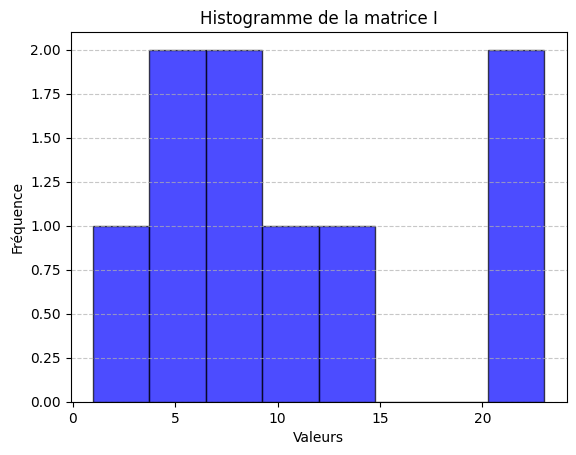

In [ ]:
# Histogramme
# Tracer l'histogramme
plt.hist(I.ravel(), bins=8, color='blue', edgecolor='black', alpha=0.7)
plt.title("Histogramme de la matrice I")
plt.xlabel("Valeurs")
plt.ylabel("Fréquence")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### l'égalisation (Image codée sur 5 bits )

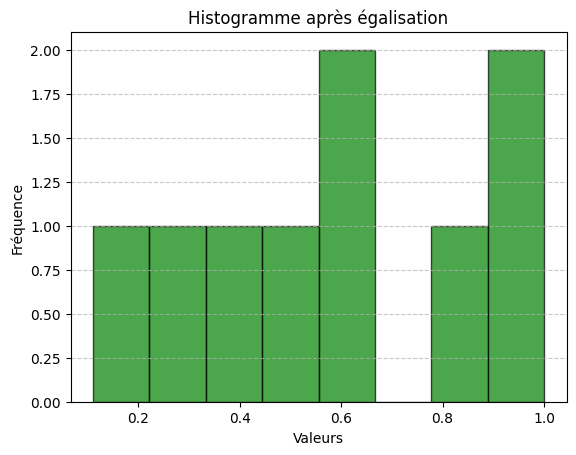

In [ ]:
from skimage import exposure
# Normaliser les valeurs pour l'égalisation (entre 0 et31)
I_normalized = ((I - np.min(I)) / (np.max(I) - np.min(I)) * 31).astype(np.uint8)

# Appliquer l'égalisation d'histogramme
I_equalized = exposure.equalize_hist(I_normalized)
# Tracer l'histogramme égalisé
plt.hist(I_equalized.ravel(), bins=8, color='green', edgecolor='black', alpha=0.7)
plt.title("Histogramme après égalisation")
plt.xlabel("Valeurs")
plt.ylabel("Fréquence")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Root Mean Square, RMS

In [ ]:
# Calcul de la racine carrée de la moyenne des carrés (RMS)
rms = np.sqrt(np.mean(I**2))

print("Root Mean Square (RMS) de l'image : ", rms)

Root Mean Square (RMS) de l'image :  12.948616399703354



### Entropie avec Ln et Entropie avec LOG2 et Entropie normalisée avec LOG2




In [ ]:
# Calcul de l'entropie avec la formule SUM I * ln(I)
entropy_ln = -np.sum(I * np.log(I))

# Calcul de l'entropie avec la formule SUM I * log2(I)
entropy_log2 = -np.sum(I * np.log2(I))

# Calcul de l'entropie normalisée avec p(I) * log2(p(I))
# Normalisation de I pour obtenir des probabilités
I_normalized = I / np.sum(I)  # p(I)
entropy_normalized = -np.sum(I_normalized * np.log2(I_normalized))

# Affichage des résultats
print("Entropie avec  ln : ", entropy_ln)
print("Entropie avec log2 : ", entropy_log2)
print("Entropie normalisée avec log2 : ", entropy_normalized)

Entropie avec  ln :  -252.28576456714086
Entropie avec log2 :  -363.97142142789465
Entropie normalisée avec log2 :  2.847630147054193


### Transposition et symétrie

In [ ]:
# Transposition et symétrie
I_transpose = I.T  # Transpose de la matrice
I_flipped = np.flip(I, axis=1)  # Flipper horizontalement
print("Transpose de I:")
print(I_transpose)
print("\n\nFlipped I:")
print(I_flipped)

Transpose de I:
[[ 1 23  6]
 [23  8 12]
 [10  5  9]]


Flipped I:
[[10 23  1]
 [ 5  8 23]
 [ 9 12  6]]


### Fourier Transform

In [ ]:
# Fourier Transform
F_transform = np.fft.fft2(I)
F_shift = np.fft.fftshift(F_transform)  # Centrer le spectre
magnitude_spectrum = 20 * np.log(np.abs(F_shift))

print("Fourier Transform Magnitude Spectrum:")
print(magnitude_spectrum)

Fourier Transform Magnitude Spectrum:
[[70.75808864 42.04692619 63.15358002]
 [56.45446898 91.49421957 56.45446898]
 [63.15358002 42.04692619 70.75808864]]


### ***Partie 2 : Quelques applications sur les images***

In [ ]:
#Creation des Matrices I1, I2, I3:
A = np.arange(0,256,4)
B= np.array([0,0,0,0,0,0,0,0])
C = np.array([0,0,1,1,1,1,0,0])
#I1 ayant 64 lignes identiques au vecteur A

I1 = np.tile(A,(64,1))
print(I1)

[[  0   4   8 ... 244 248 252]
 [  0   4   8 ... 244 248 252]
 [  0   4   8 ... 244 248 252]
 ...
 [  0   4   8 ... 244 248 252]
 [  0   4   8 ... 244 248 252]
 [  0   4   8 ... 244 248 252]]


In [ ]:
# I2 constitué d’un bloc de 4X4 de ‘1’ entouré de deux rangs de 0 (à partir des
#vecteur B et C)
I2= np.array([B,B,C,C,C,C,B,B])
print(I2)

[[0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 1 1 1 1 0 0]
 [0 0 1 1 1 1 0 0]
 [0 0 1 1 1 1 0 0]
 [0 0 1 1 1 1 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]]


In [ ]:
#c. I3 une matrice carrée obtenue par une reproduction 2x2 de la matrice I2.

I33 = np.concatenate((I2,I2), axis = 1)
I3 = np.concatenate((I33,I33), axis = 0)
print(I3)

[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 1 1 1 1 0 0 0 0 1 1 1 1 0 0]
 [0 0 1 1 1 1 0 0 0 0 1 1 1 1 0 0]
 [0 0 1 1 1 1 0 0 0 0 1 1 1 1 0 0]
 [0 0 1 1 1 1 0 0 0 0 1 1 1 1 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 1 1 1 1 0 0 0 0 1 1 1 1 0 0]
 [0 0 1 1 1 1 0 0 0 0 1 1 1 1 0 0]
 [0 0 1 1 1 1 0 0 0 0 1 1 1 1 0 0]
 [0 0 1 1 1 1 0 0 0 0 1 1 1 1 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]]


### Convertir les 3 matrices en uint8
afin de réduire l'espace mémoire et de s'assurer que les valeurs sont comprises entre 0 et 255, ce qui est le format standard pour les images en niveaux de gris

Le type de la matrice I1 avant la convertion : int64
Le type de la matrice I2 avant la convertion : int64
Le type de la matrice I3 avant la convertion : int64
Le type de la matrice I1 aprés la convertion : uint8
Le type de la matrice I2 aprés la convertion : uint8
Le type de la matrice I3 aprés la convertion : uint8


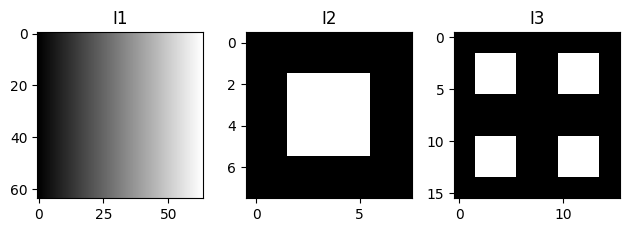

In [ ]:
#Convertir les 3 matrices en uint8
print("Le type de la matrice I1 avant la convertion :" ,I1.dtype)
print("Le type de la matrice I2 avant la convertion :" ,I2.dtype)
print("Le type de la matrice I3 avant la convertion :" ,I3.dtype)

I1 = np.uint8(I1)
I2 = np.uint8(I2)
I3 = np.uint8(I3)

print("Le type de la matrice I1 aprés la convertion :" ,I1.dtype)
print("Le type de la matrice I2 aprés la convertion :" ,I2.dtype)
print("Le type de la matrice I3 aprés la convertion :" ,I3.dtype)
#visualiser
fig, ax = plt.subplots(nrows=1, ncols=3)
ax[0].set_title("I1")
ax[0].imshow(I1,cmap='gray')
ax[1].set_title("I2")
ax[1].imshow(I2,cmap='gray')
ax[2].set_title("I3")
ax[2].imshow(I3,cmap='gray')
plt.tight_layout()

### Maintenant, nous introduisons une image

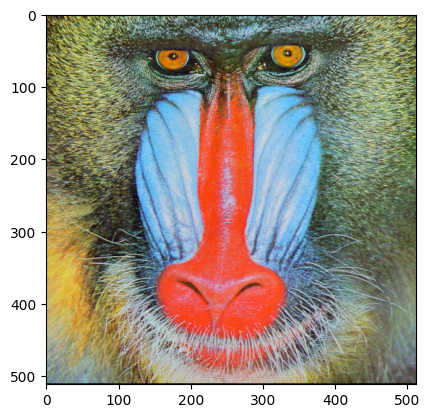

In [ ]:
#image trtmnt
path = '/content/drive/My Drive/DRIVE DOUAA-YOUSRA/img/mandrill.png'
image = cv.imread(path)
image = cv.cvtColor(image, cv.COLOR_BGR2RGB)
plt.imshow(image)



### Application de quelques opérations sur l'image
la taille et la profondeur de l’image et les canaux RGB

La taille de l'image:  (512, 512, 3)
 La profendeur de l'image:  uint8


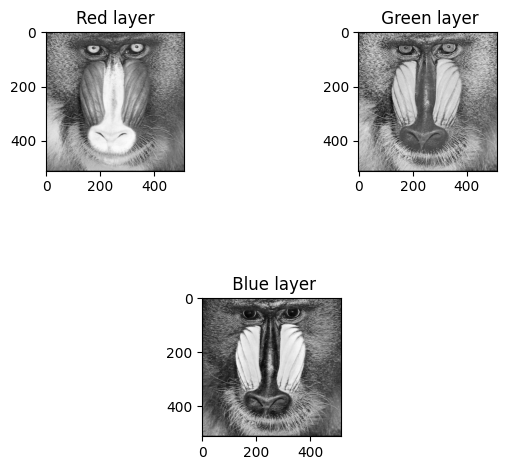

In [ ]:
# la taille et la profondeur de l’image
print("La taille de l'image:", '\033[92m', image.shape)
print('\033[30m',"La profendeur de l'image:",'\033[91m',image.dtype)
# Séparer les canaux RGB et visualiser chaque canal indépendamment
r,g,b = cv.split(image)
plot1 = plt.subplot2grid((5,4), (0,0),colspan = 2, rowspan = 2)
plot1.imshow(r, cmap = 'gray')
plot2 = plt.subplot2grid((5,4), (0,2),colspan = 2, rowspan = 2)
plot2.imshow(g, cmap = 'gray')
plot3 = plt.subplot2grid((5,4), (3,1),colspan = 2, rowspan = 2)
plot3.imshow(b, cmap= 'gray')
plot1.set_title('Red layer')
plot2.set_title(' Green layer')
plot3.set_title(' Blue layer')
plt.tight_layout()

### Intervertir l’ordre des canaux RGB

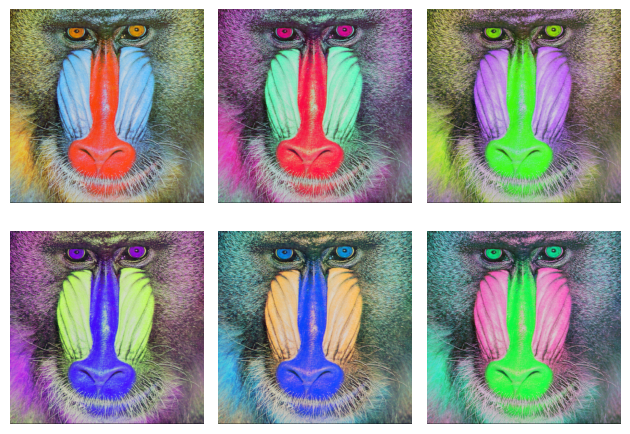

In [ ]:
#Intervertir l’ordre des canaux RGB
fig,ax = plt.subplots(nrows = 2, ncols=3)
for k in range(2):
  for j in range(3):
     ax[k,j].axis('off')

ax[0,0].imshow(cv.merge([r,g,b]))
ax[0,1].imshow(cv.merge([r,b,g]))
ax[0,2].imshow(cv.merge([g,r,b]))
ax[1,0].imshow(cv.merge([g,b,r]))
ax[1,1].imshow(cv.merge([b,g,r]))
ax[1,2].imshow(cv.merge([b,r,g]))
plt.tight_layout()

### Stocker l'image
 la composante R de l’image dans un fichier .png, la composante G dans un fichier.bmp et la composante B dans un fichier .jpeg

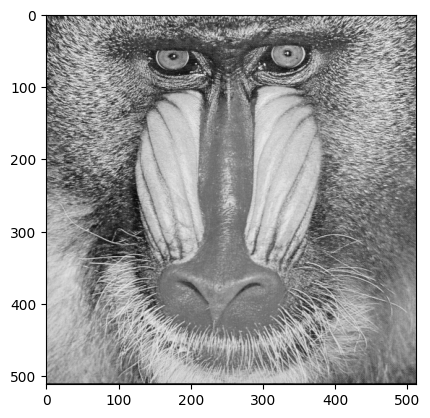

In [ ]:
#Stocker la composante R de l’image dans un fichier .png, la composante G dans un fichier
#.bmp et la composante B dans un fichier .jpeg
cv.imwrite('/content/drive/My Drive/DRIVE DOUAA-YOUSRA/imgsavedImage.png',r)
cv.imwrite('/content/drive/My Drive/DRIVE DOUAA-YOUSRA/imgsavedImage.bmp',g)
cv.imwrite('/content/drive/My Drive/DRIVE DOUAA-YOUSRA/img/savedImage.jpeg',b)
#Réaliser un passage en niveau de gris
luminance = 0.2126*r+0.7152*g+0.0722*b
plt.imshow(luminance, cmap = 'gray')

### Transformer en niveaux de gris

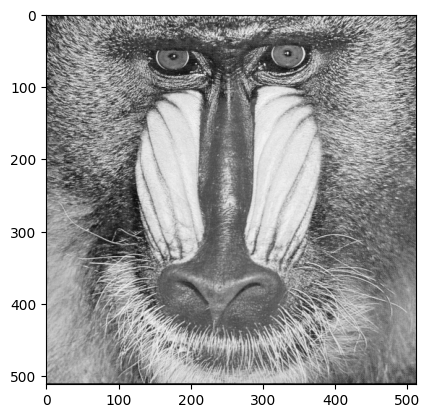

In [ ]:
#Transformer en niveaux de gris
im9 =cv.cvtColor(image, cv.COLOR_BGR2GRAY)
plt.imshow(im9, cmap = 'gray')

### l"ajout du bruit GAUSSIEN a l'image

(512, 512, 3)

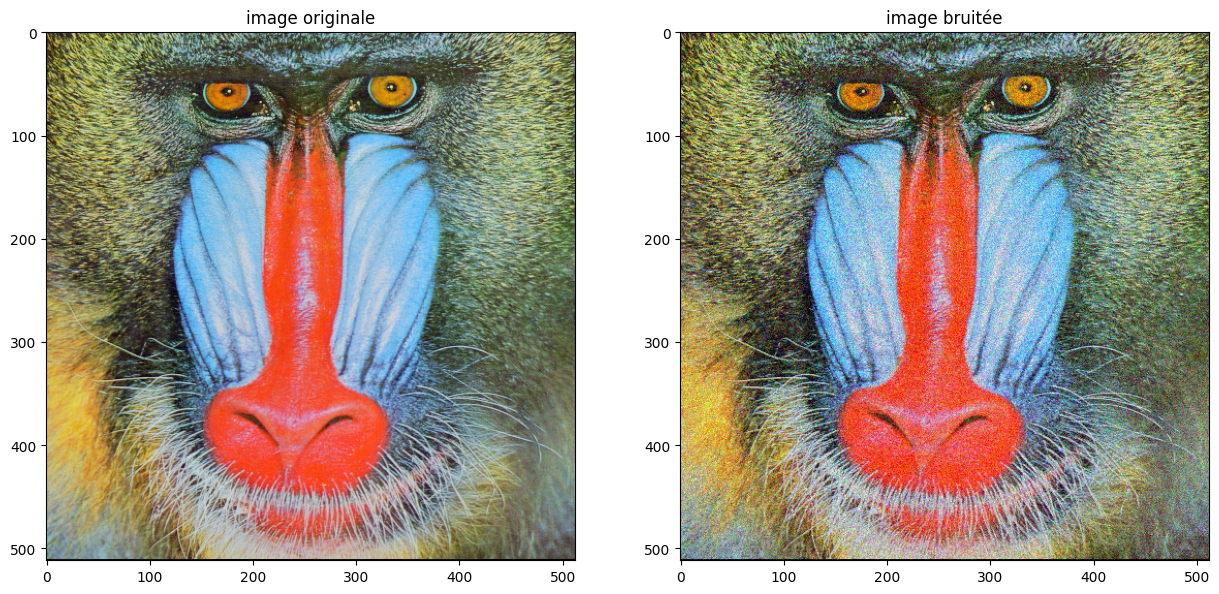

In [ ]:
Bruit_g=np.random.normal(0,0.1,image.shape)

image=image/255 # normalizer l'echelle des niveau de gris de l'image par rapport au bruit

image_Bg=image+Bruit_g

fig1=plt.figure(figsize=(15,15))
fig1.add_subplot(1,2,1)
plt.imshow(image,cmap='gray')
plt.title('image originale')
fig1.add_subplot(1,2,2)
plt.imshow(image_Bg,cmap='gray')
plt.title('image bruitée')

image.shape

### Filtre moyenneur

[0.56745867 0.38365282 0.08224455]
[0.64313725 0.58823529 0.27843137]


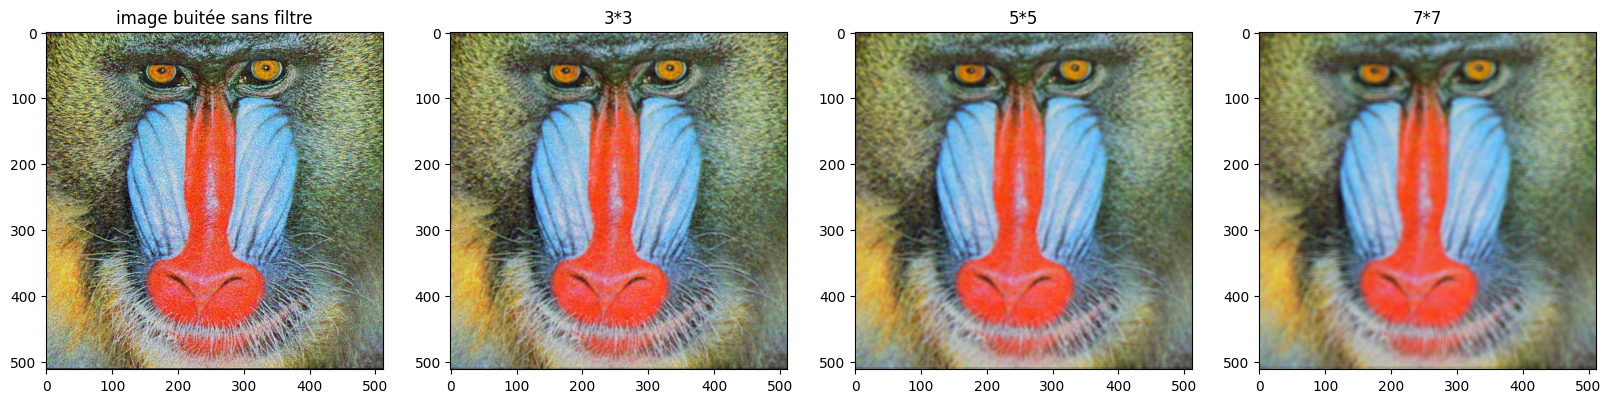

In [ ]:
image_moy_3=cv.blur(image_Bg,(3,3))


image_moy_5=cv.blur(image_Bg,(5,5))

image_moy_7=cv.blur(image_Bg,(7,7))

fig = plt.figure(figsize=(20, 20))
fig.add_subplot(1,4,1)
plt.imshow(image_Bg,cmap='gray')
plt.title("image buitée sans filtre")
fig.add_subplot(1,4,2)
plt.imshow(image_moy_3,cmap="gray")
plt.title('3*3')
fig.add_subplot(1,4,3)
plt.imshow(image_moy_5,cmap="gray")
plt.title('5*5')
fig.add_subplot(1,4,4)
plt.imshow(image_moy_7,cmap="gray")
plt.title('7*7')
  # pour comparer les valeurs des bords et voir comment ils sont traités
print(image_moy_3[0][0])
print(image[0][0])

### * Commentaire * = Ce filtre permet de réduire le bruit dans l'image, ce qui rend les zones homogènes plus lisses. Par contre, les contours sont fortement dégradés, et les structures trop fines devenienenet moins visibles, Plus la taille du filtreaugmente, plus lesdétails de l’image sont floutés. Le filtremoyenneur est un filtrepasse-bas peu robuste. **bold text**

### Filtre Mediane

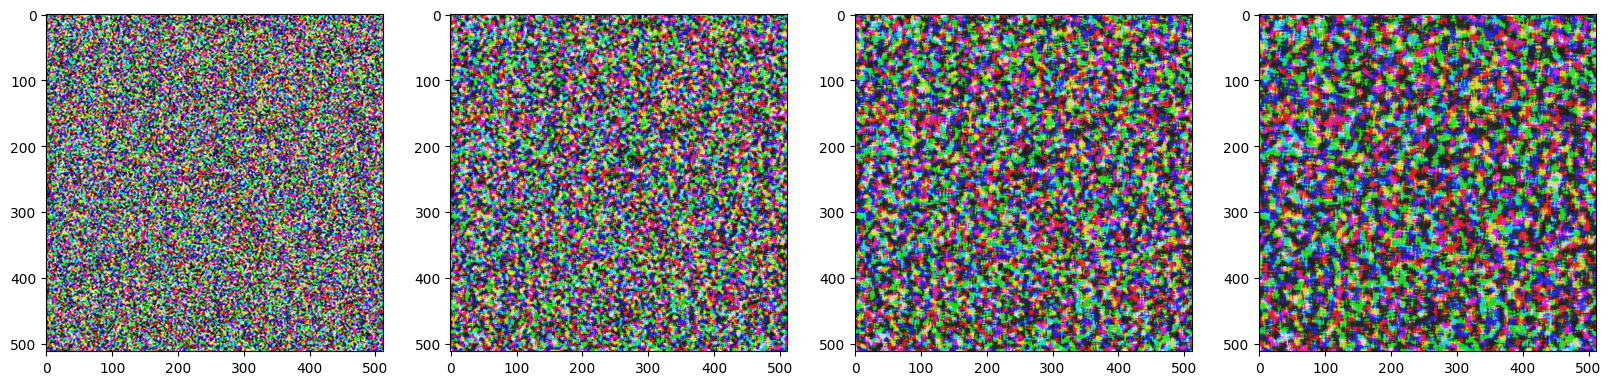

In [ ]:
fig = plt.figure(figsize=(20, 20))

Bruit_g=np.random.normal(0,0.1*255,image.shape)


image_Bg=image+Bruit_g
image_Bg=np.uint8(image_Bg)
j=1
i=3
while(i<10):
    image_median = cv.medianBlur(image_Bg,i)
    image_median= np.uint8(image_median)
    fig.add_subplot(1,4,j)
    plt.imshow(image_median,cmap='gray')

    i=i+2
    j=j+1

